In [1]:
import sys, os
sys.path.append('../src')

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm import tqdm

pd.set_option('display.width', 160)
plt.rcParams['figure.dpi'] = 110

In [2]:
import plotting as pl
import tools.evaluation as ev
from tools.dataset import load_well
from tools.spatial import PYRAMID_SCALES
from models import recipe
from models.graph import border_mask
from tools.spatial import add_mask_pyramid, add_intensity_pyramid
from tools.morphology import indices_to_mask

In [3]:
PRIMARY_WELL = 'W8_pattern1_Sox17_Brachyury'
RESULTS = '/Users/allywang/Desktop/work/F2026/OptoBMP/results/figures'
IF_BACKGROUNDS = {
    "Sox17_mean": 349.27417498634907,
    "T_mean": 384.42064880441285,
}
FIG_DIR = f'{RESULTS}/{PRIMARY_WELL}'

EPOCHS = 2500
PATIENCE = 400 
# EPOCHS = 10
# PATIENCE = 50

In [4]:
df = load_well(PRIMARY_WELL)
df.head(3)

,centroid_y,centroid_x,area,perimeter,perimeter_crofton,eccentricity,solidity,extent,major_axis_length,minor_axis_length,...,aspect_ratio,Sox17_mean,BMP4_mean,T_mean,Hoechst_mean,Sox17+,BMP4+,T+,Hoechst+,BMP4_bin
cell_id,,,,,,,,,,,,,,,,,,,,,
1,9.058548,629.522248,427.0,85.941125,84.158813,0.603269,0.908511,0.640180,27.763694,22.142602,...,1.253859,264.735363,124.067916,347.723653,1366.845433,False,False,False,True,0.0
2,9.803440,4872.491400,407.0,76.526912,75.233579,0.618904,0.946512,0.740000,26.030466,20.446056,...,1.273129,216.383292,118.837838,198.417690,758.594595,False,False,False,True,0.0
3,9.231250,7124.062500,160.0,54.970563,54.796878,0.911222,0.879121,0.661157,22.911059,9.437440,...,2.427677,226.725000,136.756250,379.668750,1362.175000,False,False,False,True,0.0


In [5]:
rng = np.random.default_rng(seed=0)
idx = rng.permutation(len(df))

df['Sox17_mean'] = df['Sox17_mean'].values[idx]
df['T_mean'] = df['T_mean'].values[idx]

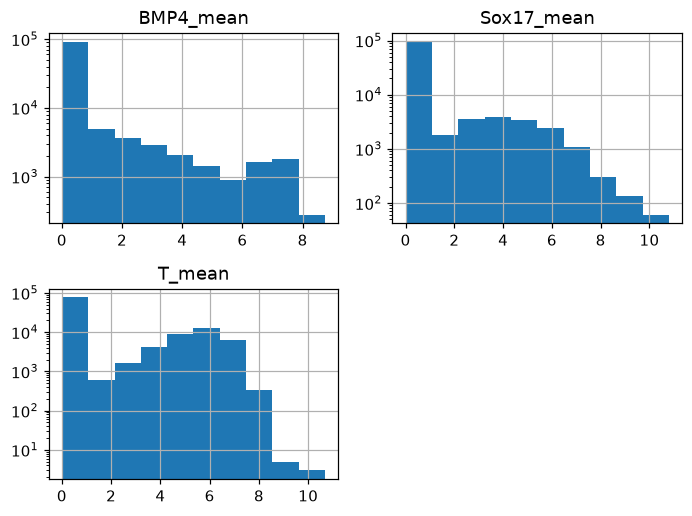

In [6]:
BACKGROUNDS = recipe.normalize(df, ['BMP4_mean', 'Sox17_mean', 'T_mean'], backgrounds=IF_BACKGROUNDS)
df[['BMP4_mean', 'Sox17_mean', 'T_mean']].hist(log=True)
plt.tight_layout()

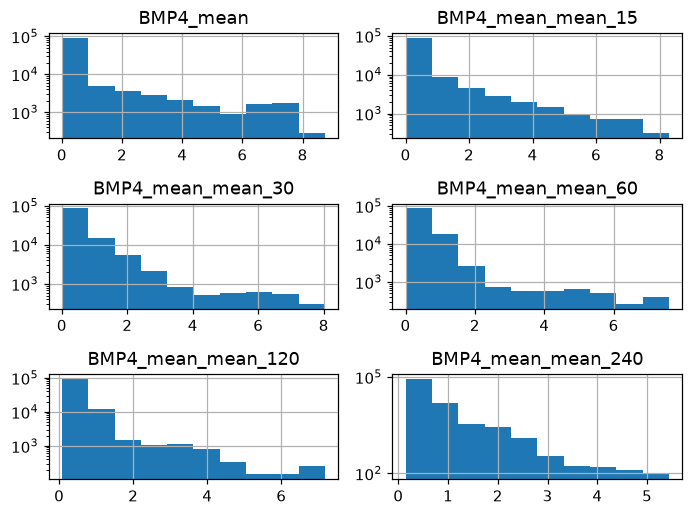

In [7]:
X_INTENSITY = recipe.intensity_features(df, 'BMP4_mean', max_sigma=recipe.MAX_SIGMA)
_ = df[X_INTENSITY].hist(log=True)
plt.tight_layout()

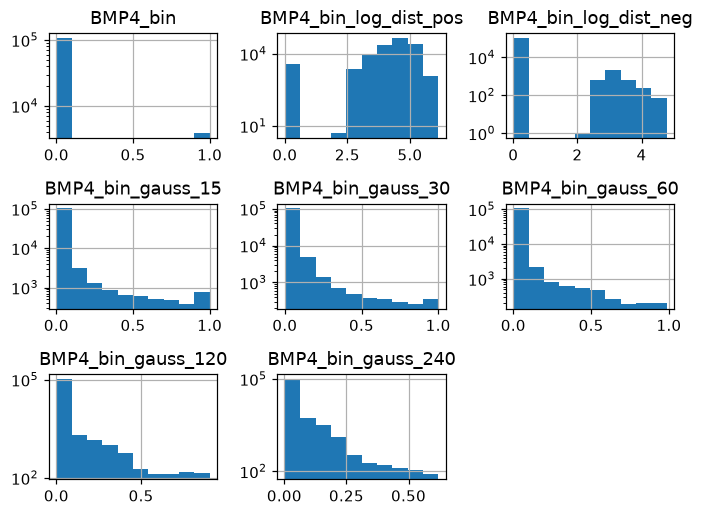

In [8]:
centroids = df[['centroid_y', 'centroid_x']].to_numpy(np.float32)
X_MASK = recipe.mask_features(df, 'BMP4_bin', max_sigma=recipe.MAX_SIGMA, geometry=True)

_ = df[X_MASK].hist(log=True)
plt.tight_layout()

In [9]:
shape = (int(centroids[:,0].max())+2, int(centroids[:,1].max())+2)
valid = np.where(~border_mask(centroids, shape, recipe.RADIUS))[0]

SPLITS = {
    'random':  tuple(valid[i] for i in ev.random_split(len(valid), seed=0)),
    'blocked': tuple(valid[i] for i in ev.spatial_block_split(centroids[valid], block=800.0, seed=0)),
}
N = len(df)
MASKS = {k: tuple(indices_to_mask(i, N) for i in v) for k, v in SPLITS.items()}
for k, (tr, va, te) in SPLITS.items():
    print(f'{k:8s} train/val/test = {len(tr):,}/{len(va):,}/{len(te):,}')

random   train/val/test = 76,681/16,432/16,432
blocked  train/val/test = 76,751/17,508/15,286


### Predict from BMP4 intensities

In [10]:
fname = 'BMP4_intensities_permuted'
cols = X_INTENSITY
os.makedirs(FIG_DIR, exist_ok=True)

In [11]:
rows, fitted = [], {}
for marker in ['Sox17', 'T']:

    y_col = f'{marker}_mean'
    
    for split_name, (tr, va, te) in SPLITS.items():
        trm, vam, tem = MASKS[split_name]

        model, data, log_w, history = recipe.fit(
            df, cols, y_col, trm, vam, tr, 
            epochs=EPOCHS, patience=PATIENCE, verbose=False)

        pred = recipe.predict(model, data, log_w)
        y = data['y'].numpy().ravel(); ypos = data['y_positive'].numpy().ravel()
        t = tem.numpy()
        met = ev.evaluate(y[t], pred[t], ypos[t])
        rows.append(dict(target=marker, split=split_name, features=fname, **met))
        fitted[(marker, split_name)] = dict(model=model, data=data, log_w=log_w, history=history,
                                                    pred=pred, y=y, ypos=ypos, metrics=met)
        print(f'{marker:6s} {split_name:8s} {fname:24s} '
                f'R2={met["r2"]:+.4f}  AUROC={met.get("auroc", float("nan")):.3f}')

results = pd.DataFrame(rows)
results.to_csv(f'{FIG_DIR}/models_{fname}.csv')
results.round(4)

Sox17  random   BMP4_intensities_permuted R2=-0.0001  AUROC=0.508
Sox17  blocked  BMP4_intensities_permuted R2=-0.0006  AUROC=0.486
T      random   BMP4_intensities_permuted R2=-0.0002  AUROC=0.499
T      blocked  BMP4_intensities_permuted R2=-0.0012  AUROC=0.497


,target,split,features,r2,pearson,spearman,auroc,ap,base_rate,r2_positives
0,Sox17,random,BMP4_intensities_permuted,-0.0001,0.0026,0.0094,0.5077,0.1570,0.1543,-3.6831
1,Sox17,blocked,BMP4_intensities_permuted,-0.0006,-0.0129,-0.0183,0.4857,0.1530,0.1580,-3.7383
2,T,random,BMP4_intensities_permuted,-0.0002,0.0017,-0.0023,0.4993,0.3181,0.3174,-7.7699
3,T,blocked,BMP4_intensities_permuted,-0.0012,-0.0036,-0.0047,0.4969,0.3090,0.3109,-8.0810


### Predict from binary mask

In [12]:
fname = 'BMP4_mask_permuted'
cols = X_MASK

In [13]:
rows, fitted = [], {}
for marker in ['Sox17', 'T']:

    y_col = f'{marker}_mean'
    
    for split_name, (tr, va, te) in SPLITS.items():
        trm, vam, tem = MASKS[split_name]

        model, data, log_w, history = recipe.fit(
            df, cols, y_col, trm, vam, tr, 
            epochs=EPOCHS, patience=PATIENCE, verbose=False)

        pred = recipe.predict(model, data, log_w)
        y = data['y'].numpy().ravel(); ypos = data['y_positive'].numpy().ravel()
        t = tem.numpy()
        met = ev.evaluate(y[t], pred[t], ypos[t])
        rows.append(dict(target=marker, split=split_name, features=fname, **met))
        fitted[(marker, split_name)] = dict(model=model, data=data, log_w=log_w, history=history,
                                                    pred=pred, y=y, ypos=ypos, metrics=met)
        print(f'{marker:6s} {split_name:8s} {fname:24s} '
                f'R2={met["r2"]:+.4f}  AUROC={met.get("auroc", float("nan")):.3f}')

results = pd.DataFrame(rows)
results.to_csv(f'{FIG_DIR}/models_{fname}.csv')
results.round(4)

Sox17  random   BMP4_mask_permuted       R2=-0.0007  AUROC=0.501
Sox17  blocked  BMP4_mask_permuted       R2=-0.0002  AUROC=0.502
T      random   BMP4_mask_permuted       R2=+0.0000  AUROC=0.503
T      blocked  BMP4_mask_permuted       R2=-0.0003  AUROC=0.499


,target,split,features,r2,pearson,spearman,auroc,ap,base_rate,r2_positives
0,Sox17,random,BMP4_mask_permuted,-0.0007,-0.0035,0.0013,0.5011,0.1545,0.1543,-3.6777
1,Sox17,blocked,BMP4_mask_permuted,-0.0002,-0.0003,0.0026,0.5017,0.1593,0.1580,-3.6989
2,T,random,BMP4_mask_permuted,0.0000,0.0080,0.0050,0.5030,0.3189,0.3174,-7.7824
3,T,blocked,BMP4_mask_permuted,-0.0003,-0.0001,-0.0001,0.4991,0.3123,0.3109,-8.1246
